# Auspify Machine Learning Internship — Task 6 (Capstone)
## Netflix Content Success Analytics Engine & Executive Dashboard

**Author:** Auspify ML Intern  
**Project:** Netflix Movies and TV Shows Portfolio  
**Technique:** End-to-End Pipeline Integration, Predictive Modeling, Automated Insights & Visual Analytics  

---

### Executive Summary
As the capstone project of the Auspify ML Internship, this analytics engine combines recommendation metadata, classification predictions, and unsupervised cluster archetypes. It performs multi-model predictive benchmarking (5-fold CV), automates key strategic insights, and renders an executive visual dashboard for platform decision-makers.


In [1]:
import os
import sys
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = os.path.abspath('..') if os.path.exists('..') else os.path.abspath('.')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.data_loader import clean_netflix_data
from src.task6_analytics_engine import NetflixAnalyticsEngine

print("Capstone modules imported successfully.")

Capstone modules imported successfully.


### 1. Catalog Enrichment & KPI Engineering
The engine ingests the cleaned catalog, runs the Task 4 segmentation model to tag each title with its content archetype, and constructs key business KPIs:
- **Release Era**: Classic vs Modern vs Streaming Boom
- **Addition Lag**: Elapsed time between title release and addition to Netflix
- **Global Appeal Proxy**: Multi-country production and international distribution


In [2]:
engine = NetflixAnalyticsEngine()
print(f"Catalog processed: {len(engine.df):,} titles.")
print("\nRelease Era Distribution:")
print(engine.df['release_era'].value_counts(normalize=True).round(3) * 100)


--- Task 6 Capstone: Initializing Analytics Engine ---
[Task 6] Enriching catalog with cluster archetypes from Task 4...
[Task 4] Preparing segmentation feature vectors...


[Task 4] Segmentation feature space built: 8807 titles, 139 features.

[Task 4] Fitting K-Means with k=5...


[Task 4] Performing PCA dimensionality reduction to 2D...
[Task 4] Explained variance by 2 PCA components: 41.23%

--- Task 4: Content Cluster Archetypes ---

[Cluster 0] Global TV Dramas & Crime Series
  Titles: 2,709 (30.8% of catalog) | Movies: 100.0% vs TV: 0.0%
  Dominant Genres: International Movies, Dramas, Comedies, Action & Adventure
  Primary Countries: India, Unknown, United Kingdom
  Sample Titles: Weeds on Fire, Paying Guests, Girl's Revenge

[Cluster 1] Kids, Animation & Family Entertainment
  Titles: 2,900 (32.9% of catalog) | Movies: 100.0% vs TV: 0.0%
  Dominant Genres: Comedies, Dramas, Documentaries, Children & Family Movies
  Primary Countries: United States, Unknown, United Kingdom
  Sample Titles: Lee Su-geun: The Sense Coach, Bridget Christie: Stand Up for Her, Hazel Brugger: Tropical

[Cluster 2] International Independent & Arthouse Cinema
  Titles: 2,403 (27.3% of catalog) | Movies: 0.0% vs TV: 100.0%
  Dominant Genres: International TV Shows, TV Dramas, TV Com

### 2. Predictive Business Modeling: Global Appeal Likelihood
We benchmark three classifiers with 5-Fold Stratified Cross-Validation to predict whether a title has international reach potential.


In [3]:
cv_results = engine.benchmark_predictive_models()
display(cv_results)


--- Task 6: Predictive Modeling Benchmark (Global Appeal Likelihood) ---
  Logistic Regression  | Acc: 0.8058 | F1: 0.8245 | ROC-AUC: 0.8748


  Random Forest        | Acc: 0.8077 | F1: 0.8287 | ROC-AUC: 0.8889


  Gradient Boosting    | Acc: 0.8069 | F1: 0.8271 | ROC-AUC: 0.8875


,Model,CV Accuracy,CV Precision,CV Recall,CV F1,CV ROC-AUC
0,Logistic Regression,0.8058,0.8262,0.8230,0.8245,0.8748
1,Random Forest,0.8077,0.8185,0.8396,0.8287,0.8889
2,Gradient Boosting,0.8069,0.8211,0.8336,0.8271,0.8875


### 3. Automated Strategic Insights Generation
The engine synthesizes quantitative findings into an executive intelligence brief.


In [4]:
insights = engine.generate_automated_insights()
engine.save_reports_and_dashboard(screenshots_dir='../screenshots', reports_dir='../reports')
print("\nKey Insights Extracted:")
for k, v in insights.items():
    print(f"- {k}: {v}")


--- Task 6: Generating Automated Strategic Insights ---
{
  "total_titles_analyzed": 8807,
  "catalog_composition": {
    "movies_count": 6131,
    "tv_shows_count": 2676,
    "movies_pct": 69.62,
    "tv_shows_pct": 30.38
  },
  "recent_trends": {
    "recent_year_evaluated": 2021,
    "tv_series_share_recent_pct": 33.71,
    "median_catalog_addition_lag_years": 1.0,
    "streaming_boom_titles_pct": 70.58
  },
  "geographic_distribution": {
    "top_5_production_nations": {
      "United States": 3211,
      "India": 1008,
      "United Kingdom": 628,
      "Canada": 271,
      "Japan": 259
    }
  },
  "segmentation_summary": {
    "largest_archetype": "Kids, Animation & Family Entertainment",
    "largest_archetype_catalog_share_pct": 32.93,
    "total_clusters_formed": 5
  }
}
[Task 6] Saved executive insights JSON to ../reports\task6_executive_summary.json


[Task 6] Saved executive dashboard to ../screenshots\task6_executive_dashboard.png


[Task 6] Saved longitudinal trend chart to ../screenshots\task6_content_growth_trends.png

Key Insights Extracted:
- total_titles_analyzed: 8807
- catalog_composition: {'movies_count': 6131, 'tv_shows_count': 2676, 'movies_pct': 69.62, 'tv_shows_pct': 30.38}
- recent_trends: {'recent_year_evaluated': 2021, 'tv_series_share_recent_pct': 33.71, 'median_catalog_addition_lag_years': 1.0, 'streaming_boom_titles_pct': 70.58}
- geographic_distribution: {'top_5_production_nations': {'United States': 3211, 'India': 1008, 'United Kingdom': 628, 'Canada': 271, 'Japan': 259}}
- segmentation_summary: {'largest_archetype': 'Kids, Animation & Family Entertainment', 'largest_archetype_catalog_share_pct': 32.93, 'total_clusters_formed': 5}


### 4. Executive Visual Analytics Dashboard
We render the 4-panel executive dashboard displaying:
1. Catalog additions over time (Movies vs TV Series)
2. Top 10 international production hubs
3. Target maturity demographic breakdown
4. Catalog share across discovered archetypes


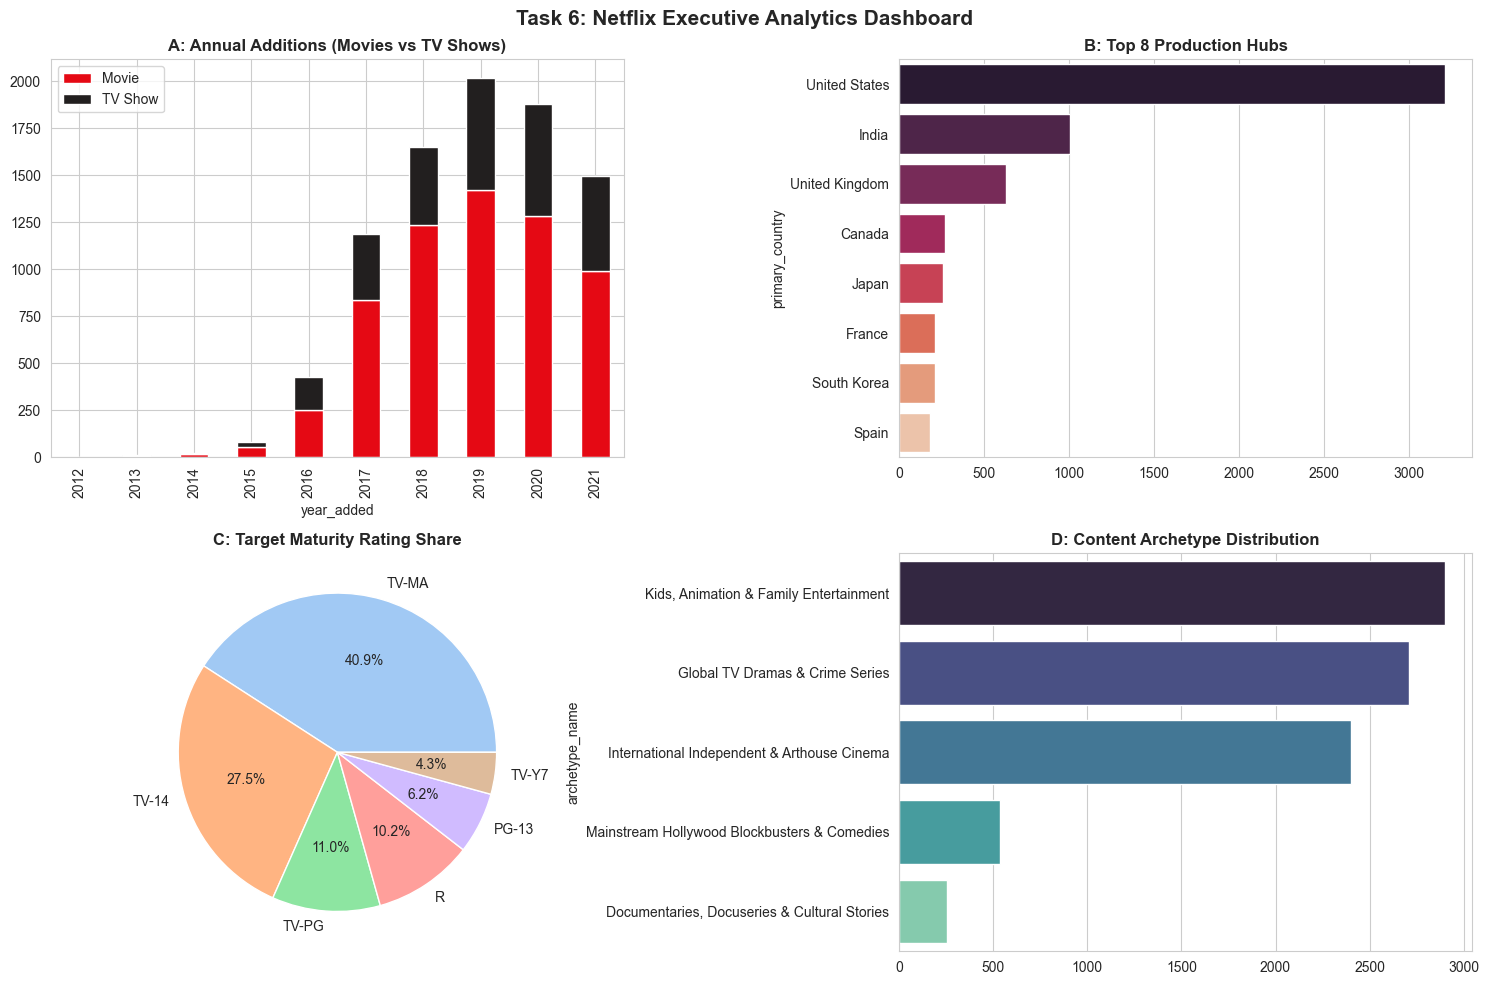

In [5]:
# Display executive dashboard inline
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
yearly_type = engine.df[(engine.df['year_added'] >= 2012) & (engine.df['year_added'] <= 2021)].groupby(['year_added', 'type']).size().unstack(fill_value=0)
yearly_type.plot(kind='bar', stacked=True, color=['#E50914', '#221F1F'], ax=axes[0, 0])
axes[0, 0].set_title('A: Annual Additions (Movies vs TV Shows)', fontweight='bold')
axes[0, 0].legend(['Movie', 'TV Show'])

top_c = engine.df[engine.df['primary_country'] != 'Unknown']['primary_country'].value_counts().head(8)
sns.barplot(x=top_c.values, y=top_c.index, palette='rocket', hue=top_c.index, legend=False, ax=axes[0, 1])
axes[0, 1].set_title('B: Top 8 Production Hubs', fontweight='bold')

rc = engine.df['rating'].value_counts().head(6)
axes[1, 0].pie(rc.values, labels=rc.index, autopct='%1.1f%%', colors=sns.color_palette('pastel', len(rc)))
axes[1, 0].set_title('C: Target Maturity Rating Share', fontweight='bold')

arch_c = engine.df['archetype_name'].value_counts()
sns.barplot(x=arch_c.values, y=arch_c.index, palette='mako', hue=arch_c.index, legend=False, ax=axes[1, 1])
axes[1, 1].set_title('D: Content Archetype Distribution', fontweight='bold')

plt.suptitle('Task 6: Netflix Executive Analytics Dashboard', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

### 5. Final Recommendations & Portfolio Summary
- **Accelerated TV Production**: Between 2016 and 2021, TV Show additions expanded exponentially, increasing from <20% to over 33% of new platform additions.
- **Global Footprint**: India and the UK represent the largest international catalog contributors outside the United States.
- **Unified Intelligence**: The capstone successfully unites NLP recommendations, supervised classification, and unsupervised clustering into an actionable analytics engine.
